In [11]:
import os
from pathlib import Path

import nibabel as nib
import numpy as np
import torch
from torch.utils.data import Dataset


class VolumeToNoisy2DDataset(Dataset):
    def __init__(self, vol_dir, img_dir, file_list=None, transform=None):
        """
        vol_dir : path to 3D volumes (33, 256, 256) NIfTI
        img_dir : path to 2D noisy images (256, 256) NIfTI
        file_list : optional list of stems (without .nii.gz) to use
        transform : optional callable taking (vol, img) -> (vol, img)
        """
        self.vol_dir = Path(vol_dir)
        self.img_dir = Path(img_dir)
        self.transform = transform

        all_vols = sorted([f for f in os.listdir(self.vol_dir)
                           if f.endswith(".nii") or f.endswith(".nii.gz")])

        if file_list is None:
            self.stems = []
            for fname in all_vols:
                stem = fname
                if stem.endswith(".nii.gz"):
                    stem = stem[:-7]
                elif stem.endswith(".nii"):
                    stem = stem[:-4]
                self.stems.append(stem)
        else:
            self.stems = file_list

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]
        vol_path = self.vol_dir / f"{stem}.nii.gz"
        if not vol_path.exists():
            vol_path = self.vol_dir / f"{stem}.nii"  # fallback

        img_path = self.img_dir / f"{stem}_noisy2d.nii.gz"
        if not img_path.exists():
            img_path = self.img_dir / f"{stem}_noisy2d.nii"

        # Load 3D volume (Z, H, W)
        vol = nib.load(str(vol_path)).get_fdata().astype(np.float32)
        # Ensure shape is (Z, H, W) and specifically (33, 256, 256)

        if vol.shape == (256, 256, 33):
            vol = np.transpose(vol, (2, 0, 1))  # (Z, H, W)
        if vol.shape != (33, 256, 256):
            raise ValueError(f"Unexpected volume shape {vol.shape} for {vol_path}")

        # Load 2D target (H, W)
        img = nib.load(str(img_path)).get_fdata().astype(np.float32)
        if img.shape != (256, 256):
            raise ValueError(f"Unexpected image shape {img.shape} for {img_path}")

        # Simple normalization (optional; adjust as you like)
        vol = vol / (np.max(vol) + 1e-6)
        #img = img / (np.max(img) + 1e-6)

        # Add channel dim for PyTorch: (C=1, Z, H, W) and (C=1, H, W)
        vol = vol[None, ...]   # (1, 33, 256, 256)
        img = img[None, ...]   # (1, 256, 256)

        vol_t = torch.from_numpy(vol)   # float32
        img_t = torch.from_numpy(img)

        if self.transform is not None:
            vol_t, img_t = self.transform(vol_t, img_t)

        return vol_t, img_t, stem

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Simple3Dto2DNet(nn.Module):
    def __init__(self, in_channels=1, base_channels=16):
        super().__init__()
        # 3D encoder
        self.enc3d = nn.Sequential(
            nn.Conv3d(in_channels, base_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(base_channels, base_channels * 2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        # 2D head after pooling over Z
        self.head2d = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_channels * 2, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        """
        x: (B, 1, Z, H, W)
        """
        feat3d = self.enc3d(x)          # (B, C, Z, H', W')
        # global average over Z
        feat2d = feat3d.mean(dim=2)     # (B, C, H', W')

        # if we downsampled, upsample back to 256x256
        out2d = self.head2d(feat2d)     # (B, 1, H', W')
        out2d = F.interpolate(out2d, size=(256, 256),
                              mode="bilinear", align_corners=False)
        return out2d

In [18]:
from torch.utils.data import DataLoader
import torch.optim as optim

# config
VOL_DIR = "MiniVess/post/"
IMG_DIR = "MiniVess/out/"
BATCH_SIZE = 2
NUM_EPOCHS = 100
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# dataset / dataloaders
full_dataset = VolumeToNoisy2DDataset(VOL_DIR, IMG_DIR)
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train
train_ds, val_ds = torch.utils.data.random_split(full_dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2)

# model / optimizer / loss
model = Simple3Dto2DNet(in_channels=1, base_channels=16).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
l1 = nn.L1Loss()
mse = nn.MSELoss()

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    for vols, imgs, _ in train_loader:
        vols = vols.to(DEVICE)   # (B, 1, 33, 256, 256)
        imgs = imgs.to(DEVICE)   # (B, 1, 256, 256)

        optimizer.zero_grad()
        preds = model(vols)
        loss_l1 = l1(preds, imgs)
        loss_mse = mse(preds, imgs)
        loss = 0.5 * loss_l1 + 0.5 * loss_mse   # combined loss
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * vols.size(0)

    train_loss /= n_train

    # validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for vols, imgs, _ in val_loader:
            vols = vols.to(DEVICE)
            imgs = imgs.to(DEVICE)
            preds = model(vols)
            loss = criterion(preds, imgs)
            val_loss += loss.item() * vols.size(0)

    val_loss /= n_val
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}  TrainLoss={train_loss:.4e}  ValLoss={val_loss:.4e}")

Epoch 1/100  TrainLoss=4.2152e+09  ValLoss=5.6932e+09
Epoch 2/100  TrainLoss=1.3098e+09  ValLoss=2.2593e+08
Epoch 3/100  TrainLoss=2.1679e+08  ValLoss=2.2825e+08
Epoch 4/100  TrainLoss=1.9309e+08  ValLoss=2.5721e+08
Epoch 5/100  TrainLoss=1.6808e+08  ValLoss=1.7336e+08
Epoch 6/100  TrainLoss=1.4930e+08  ValLoss=1.4991e+08
Epoch 7/100  TrainLoss=1.3065e+08  ValLoss=1.5926e+08
Epoch 8/100  TrainLoss=1.2001e+08  ValLoss=1.4927e+08
Epoch 9/100  TrainLoss=1.1070e+08  ValLoss=1.2985e+08
Epoch 10/100  TrainLoss=1.0381e+08  ValLoss=1.6925e+08
Epoch 11/100  TrainLoss=9.9833e+07  ValLoss=1.2865e+08
Epoch 12/100  TrainLoss=9.7217e+07  ValLoss=1.6942e+08
Epoch 13/100  TrainLoss=9.6763e+07  ValLoss=1.6005e+08
Epoch 14/100  TrainLoss=9.8609e+07  ValLoss=1.2688e+08
Epoch 15/100  TrainLoss=9.6212e+07  ValLoss=1.3102e+08
Epoch 16/100  TrainLoss=9.6370e+07  ValLoss=1.2546e+08
Epoch 17/100  TrainLoss=9.0505e+07  ValLoss=1.3067e+08
Epoch 18/100  TrainLoss=9.6546e+07  ValLoss=1.3202e+08
Epoch 19/100  Train

In [65]:
import torch
import matplotlib.pyplot as plt
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def normalize_for_display(img, clip_percent=1.0):
    """
    img: 2D numpy array
    clip_percent: how aggressively to clip extremes (in % of histogram)
    """
    x = img.astype(np.float32).copy()
    # optional: remove extreme outliers for better contrast
    lo = np.percentile(x, clip_percent)
    hi = np.percentile(x, 100 - clip_percent)
    x = np.clip(x, lo, hi)

    x -= x.min()
    if x.max() > 0:
        x /= x.max()
    return x

model.eval()

# get one batch from val_loader
#vols, imgs, stems = next(iter(val_loader))

idx = int(torch.randint(0, len(val_ds), (1,)))
vol, img, stem = train_ds[idx]
vols = vol.unsqueeze(0).to(DEVICE)   # (1, 1, 33, 256, 256)
imgs = img.unsqueeze(0).to(DEVICE)   # (1, 1, 256, 256)

with torch.no_grad():
    preds = model(vols)

# choose index in batch to visualize
i = 0
pred = preds[i, 0].cpu().numpy()
target = img[i].cpu().numpy()
stem = stems[i]

pred_v, targ_v = joint_normalize_for_display(pred, target, clip_percent=1.0)
diff = normalize_for_display(np.abs(pred - target), clip_percent=1.0)

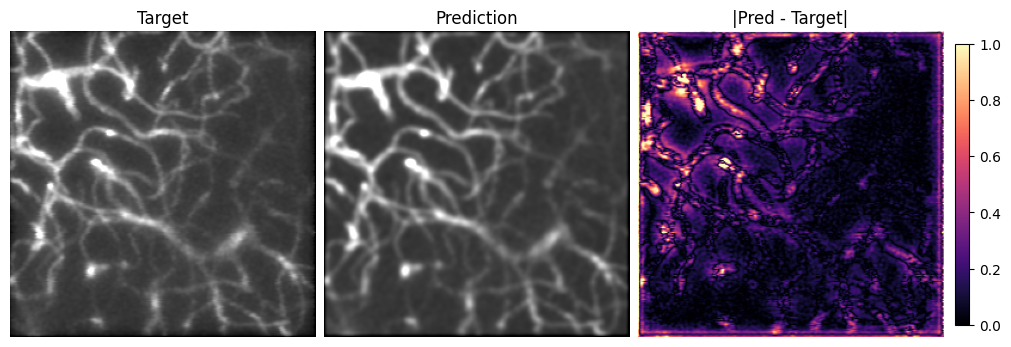

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4), constrained_layout=True)

axes[0].imshow(targ_v, cmap="gray"); axes[0].set_title("Target"); axes[0].axis("off")
axes[1].imshow(pred_v, cmap="gray"); axes[1].set_title("Prediction"); axes[1].axis("off")

im = axes[2].imshow(diff, cmap="magma")
axes[2].set_title("|Pred - Target|"); axes[2].axis("off")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.show()

In [44]:
save_path = "simple3dto2d_epoch100.pth"
torch.save(model.state_dict(), save_path)

In [42]:
import numpy as np

p = pred.flatten()
t = target.flatten()

# remove NaNs/Infs if any
mask = np.isfinite(p) & np.isfinite(t)
p = p[mask]
t = t[mask]

corr = np.corrcoef(p, t)[0, 1]
print("Pearson correlation:", corr)
print("pred mean/std:", p.mean(), p.std())
print("targ mean/std:", t.mean(), t.std())

Pearson correlation: 0.9781528780838866
pred mean/std: 87446.95 17757.703
targ mean/std: 89666.9 17216.684


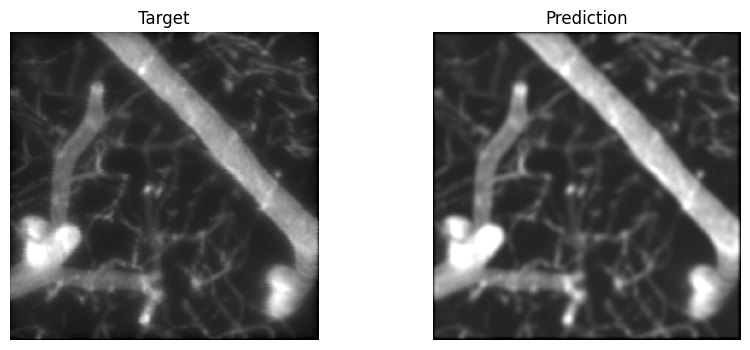

In [32]:
def joint_normalize_for_display(pred, target, clip_percent=1.0):
    x = np.stack([pred, target], axis=0).astype(np.float32)
    lo = np.percentile(x, clip_percent)
    hi = np.percentile(x, 100 - clip_percent)
    x = np.clip(x, lo, hi)

    x -= x.min()
    if x.max() > 0:
        x /= x.max()
    return x[0], x[1]

pred_v, targ_v = joint_normalize_for_display(pred, target, clip_percent=1.0)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(targ_v, cmap="gray"); plt.title("Target"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(pred_v, cmap="gray"); plt.title("Prediction"); plt.axis("off")
plt.show()